In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("Telco_customer_churn.xlsx")

In [3]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


In [4]:
df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [11]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [12]:
df = df.dropna()

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7032 non-null   object 
 1   Senior Citizen     7032 non-null   object 
 2   Partner            7032 non-null   object 
 3   Dependents         7032 non-null   object 
 4   Tenure Months      7032 non-null   int64  
 5   Phone Service      7032 non-null   object 
 6   Multiple Lines     7032 non-null   object 
 7   Internet Service   7032 non-null   object 
 8   Online Security    7032 non-null   object 
 9   Online Backup      7032 non-null   object 
 10  Device Protection  7032 non-null   object 
 11  Tech Support       7032 non-null   object 
 12  Streaming TV       7032 non-null   object 
 13  Streaming Movies   7032 non-null   object 
 14  Contract           7032 non-null   object 
 15  Paperless Billing  7032 non-null   object 
 16  Payment Method     7032 non-n

In [14]:
X = df.drop("Churn Value", axis=1)
y = df["Churn Value"]

In [15]:
X = pd.get_dummies(X, drop_first=True)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Logistic regression

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Evaluate model

In [18]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8123667377398721
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1012
           1       0.70      0.58      0.63       395

    accuracy                           0.81      1407
   macro avg       0.77      0.74      0.75      1407
weighted avg       0.81      0.81      0.81      1407



Random Forest

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7931769722814499
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1012
           1       0.68      0.51      0.58       395

    accuracy                           0.79      1407
   macro avg       0.75      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



XGBoost.

In [20]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7825159914712153
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1012
           1       0.63      0.55      0.59       395

    accuracy                           0.78      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.78      0.78      1407



AUC SCORE

In [21]:
from sklearn.metrics import roc_auc_score

y_prob = xgb.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

AUC Score: 0.8405701205783759


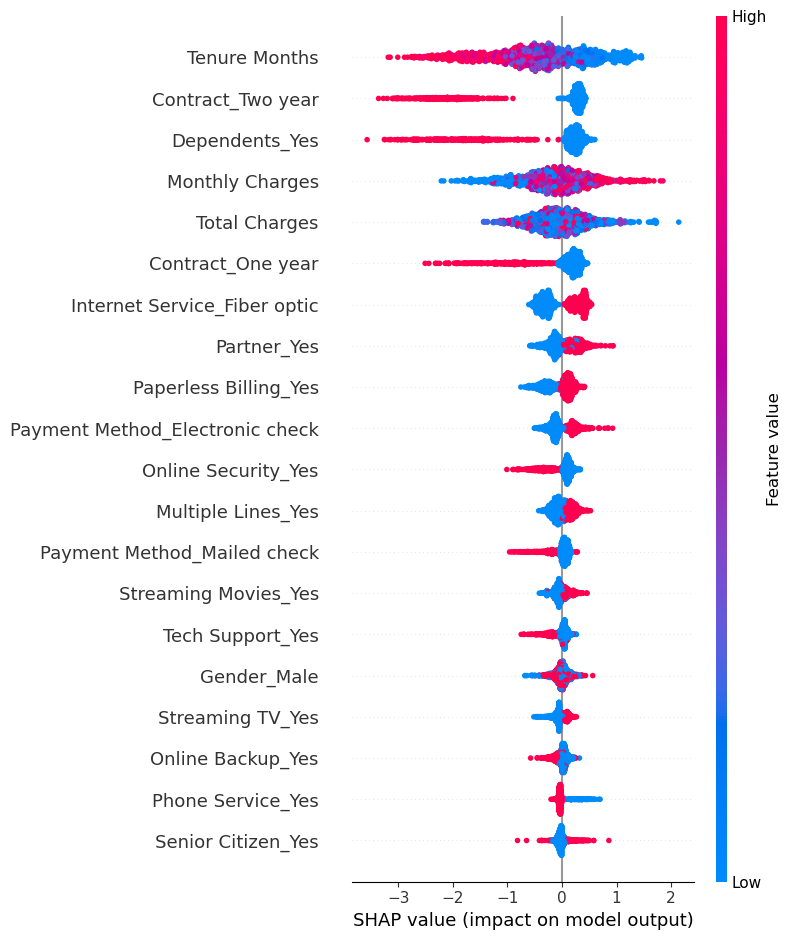

In [33]:
import shap
fig = plt.figure()
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

save_path = 'shap.summary_plot.png'
fig.savefig(save_path) #save the figure object
plt.close(fig)

In [24]:
import numpy as np

feature_importance = np.abs(shap_values).mean(0)
feature_names = X_test.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df.head(5)

,Feature,Importance
0,Tenure Months,0.799470
25,Contract_Two year,0.740157
6,Dependents_Yes,0.585329
1,Monthly Charges,0.488219
2,Total Charges,0.379282


In [23]:
LogisticRegression(max_iter=1000, class_weight="balanced")

LogisticRegression(class_weight='balanced', max_iter=1000)

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [26]:
y_prob = xgb.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("AUC:", auc_score)

AUC: 0.8405701205783759


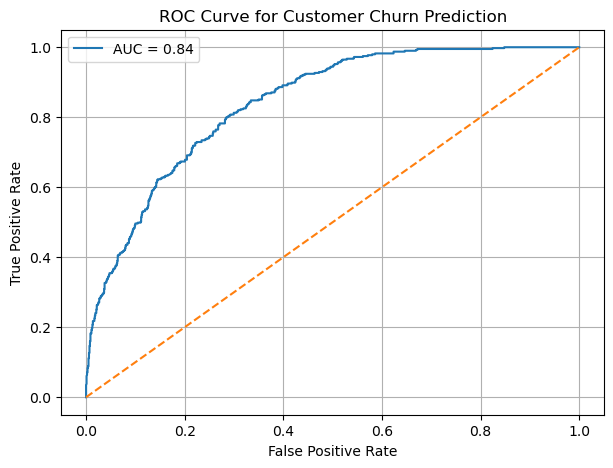

In [27]:
plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Customer Churn Prediction")

plt.legend()
plt.grid()

plt.show()

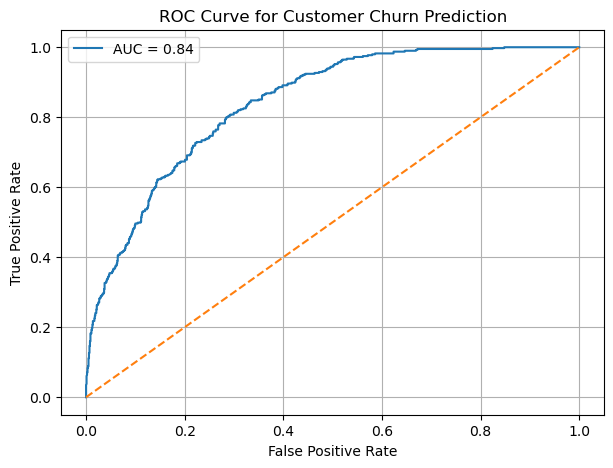

In [29]:
plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Customer Churn Prediction")

plt.legend()
plt.grid()

plt.savefig("roc_curve_churn.png", dpi=300, bbox_inches="tight")

plt.show()

In [35]:
import streamlit as st

st.title("Customer Churn Prediction Dashboard")

st.write("This dashboard predicts customer churn risk.")

2026-03-07 09:50:32.319 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-07 09:50:32.326 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-07 09:50:32.330 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-07 09:50:32.332 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
